In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [14]:
import json
import numpy as np
import scipy
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import glob
import os
from pathlib import Path
import sys
import pandas as pd

import cogwheel.likelihood
import cogwheel.data
from cogwheel.plotting import latex_val_err
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors
import gwosc
import gwpy.table
from pesummary.io import read

sys.path.insert(0, '../code')
import make_event_data
from parameter_estimation import get_chirp_mass, get_table_data, add_derived_quantities, get_event_data

In [3]:
# helper function to get median values
def get_medians(samples, corner_plot):
    medians = {}
    for key in samples.keys():
        medians[key] = corner_plot._get_median_and_central_interval(key)[0]
    return medians

In [4]:
# load samples from event posterior(s)

# where we've saved the posteriors and samples
resdir = '../data/pe_runs_lensing/IntrinsicLVCPrior'

# list of event directories
event_dir_list = glob.glob(f'{resdir}/GW*')
eventname_list = [
    event_dir.split('/')[-1] for event_dir in event_dir_list
]
print(f"found {len(eventname_list)} events")

found 17 events


In [10]:
def load_posterior_samples(eventname, event_path):
    # find the "earliest" run with posterior samples
    i = 0
    samples = None
    while i < 10:
        try:
            samples = pd.read_feather(os.path.join(event_path, f'run_{i}', 'samples.feather'))
            print(f"loaded posterior samples for {eventname} run {i}")
            break
        except FileNotFoundError:
            i += 1
    if samples is None:
        print(f"no samples found for {eventname}")
        return None, None

    # add derived quantities
    add_derived_quantities(samples)

    # load the posterior samples from the LIGO PE data release
    try:
        pe_data_fn = f"../data/pe_data_release/IGWN-GWTC4p0-1a206db3d_721-{eventname}-combined_PEDataRelease.hdf5"
        data = read(pe_data_fn)
        # get the posterior samples using the IMRPhenomXPHM approximant
        samples_lvk = data.samples_dict["C00:IMRPhenomXPHM-SpinTaylor"]
    except FileNotFoundError:
        print(f"PE data release not found for {eventname}")
        samples_lvk = None

    return samples, samples_lvk

In [6]:
def plot_p_lensed(samples, eventname=None, return_ax=False, **kwargs):
    cp = cogwheel.gw_plotting.CornerPlot(
        samples, params=['p_lensed'], tail_probability=1e-4
    )
    hist, edges = np.histogram(samples['p_lensed'], bins=100,
                               weights=samples['weights'])
    # we want the pdf at edges, not midpoints:
    pdf = np.array([hist[0], *(hist[1:] + hist[:-1]) / 2, hist[-1]])
    
    fig, ax = plt.subplots(figsize=(5,4))
    ax.plot(edges, pdf, c='navy', alpha=0.9, **kwargs)
    ax.axvline(0.5, c='k', alpha=0.5, ls='--', lw=1.)
    ax.set_xlabel('p_lensed')
    ax.set_xlim(0., 1.)
    ax.set_ylim(0., None)
    
    # vlines
    median, *span = cp._get_median_and_central_interval('p_lensed')
    for val in (median, *span):
        ax.plot([val] * 2, [0, np.interp(val, edges, pdf)], c='navy', alpha=0.8, lw=0.5)
    idx = (edges > span[0]) & (edges < span[1])
    ax.fill_between(edges[idx], np.zeros_like(pdf[idx]), pdf[idx], color='navy', alpha=0.1)
    val_err_str = '${}={}$' + latex_val_err(median, np.subtract(median, span))
    title_str = "p_lensed" if eventname is None else f"{eventname}: p_lensed"
    ax.set_title(title_str + val_err_str)
    if return_ax:
        return ax

In [7]:
# plot parameters for our cogwheel results:
plot_params = [
    'mchirp',
    'm1',
    'm2',
    'chieff',
    'd_luminosity',
    'ra',
    'dec',
    'p_lensed'
]

In [8]:
# number of resamples
n_resamples = 1000

loaded posterior samples for GW230518_125908 run 0


2026-01-09  11:24:40 PESummary WARNING : Tidal deformability parameters found in the posterior table but they are all exactly 0. Assuming this is a BBH system.
2026-01-09  11:24:40 PESummary WARNING : Posterior samples for lambda_1 and lambda_2 found in the posterior table but lambda_1 is always exactly 0. Assuming this is an NSBH system.
2026-01-09  11:24:40 PESummary WARNING : Tidal deformability parameters found in the posterior table but they are all exactly 0. Assuming this is a BBH system.
2026-01-09  11:24:40 PESummary WARNING : Posterior samples for lambda_1 and lambda_2 found in the posterior table but lambda_1 is always exactly 0. Assuming this is an NSBH system.
2026-01-09  11:24:40 PESummary WARNING : You have supplied the waveform model: 'IMRPhenomPv2_NRTidalv2'. Currently only the IMRPhenomNSBH waveform model can be used. Unable to calculate the NSBH conversion
2026-01-09  11:24:40 PESummary WARNING : You have supplied the waveform model: 'IMRPhenomPv2_NRTidalv2'. Current

loaded posterior samples for GW230628_231200 run 1
loaded posterior samples for GW230924_124453 run 0
PE data release not found for GW230924_124453
loaded posterior samples for GW231108_125142 run 0
PE data release not found for GW231108_125142
loaded posterior samples for GW231206_233134 run 0
PE data release not found for GW231206_233134
loaded posterior samples for GW230630_234532 run 0
PE data release not found for GW230630_234532
loaded posterior samples for GW231206_233901 run 0
loaded posterior samples for GW231028_153006 run 0
loaded posterior samples for GW230914_111401 run 0
loaded posterior samples for GW240104_164932 run 0
loaded posterior samples for GW231226_101520 run 0
loaded posterior samples for GW230814_230901 run 0
loaded posterior samples for GW231102_071736 run 0
loaded posterior samples for GW230627_015337 run 0
loaded posterior samples for GW230919_215712 run 0
no samples found for GW231123_135430
loaded posterior samples for GW230927_153832 run 0


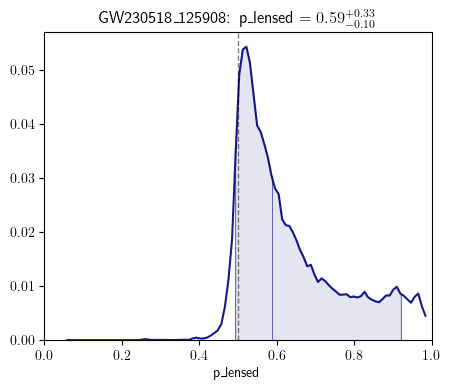

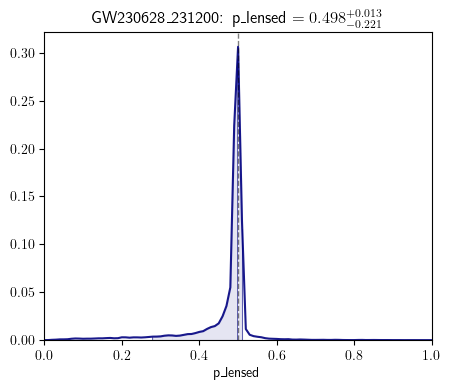

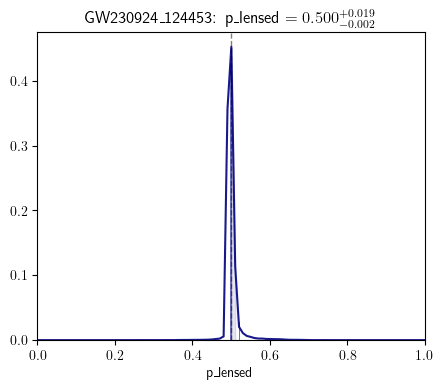

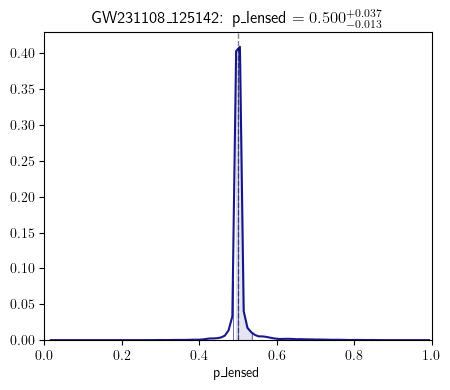

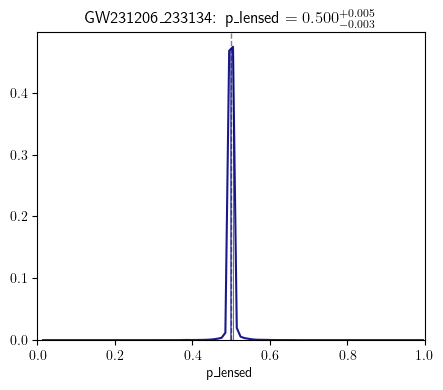

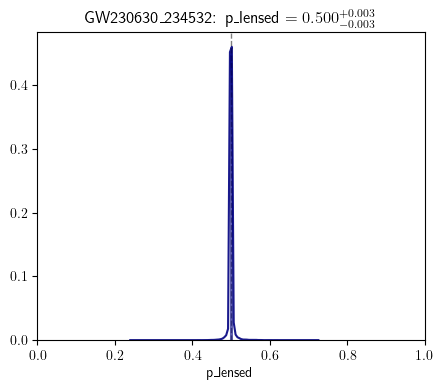

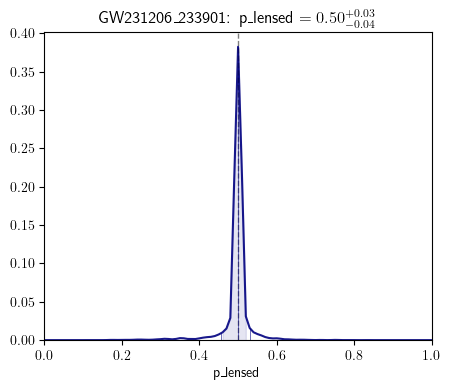

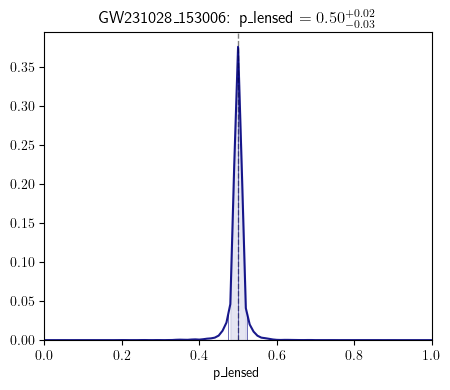

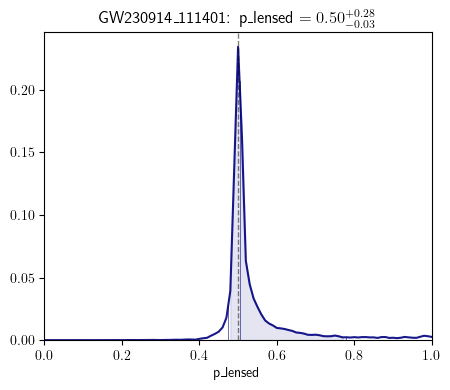

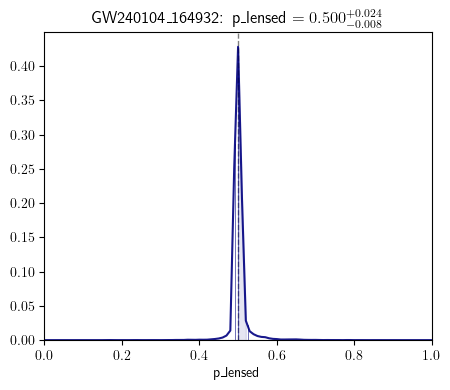

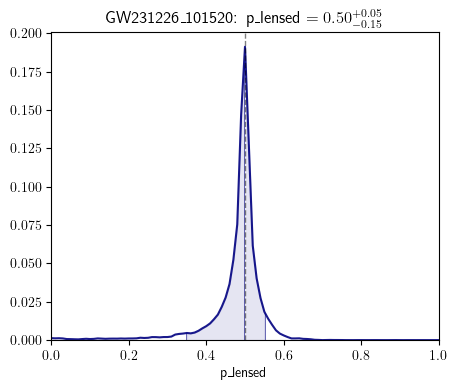

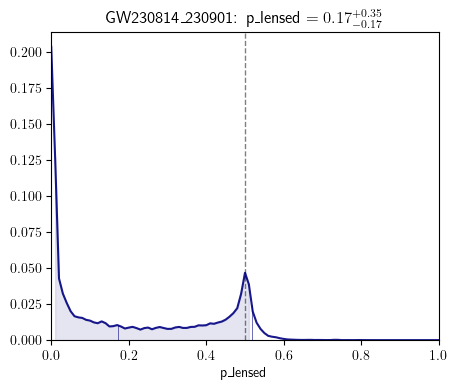

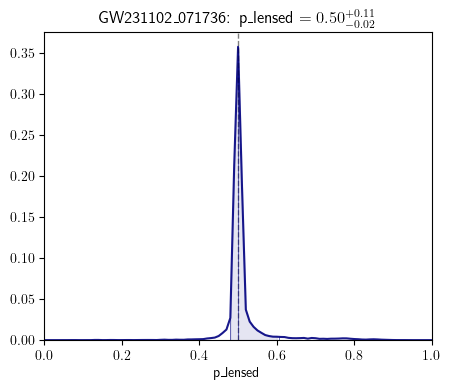

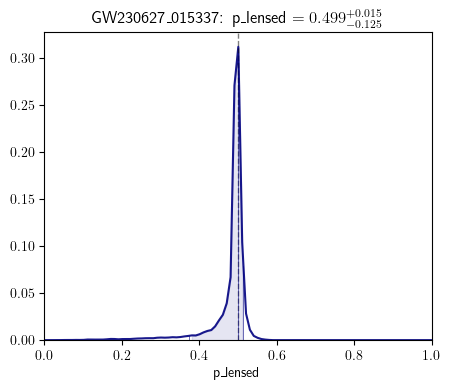

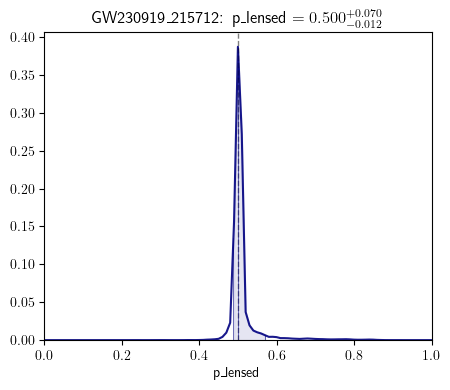

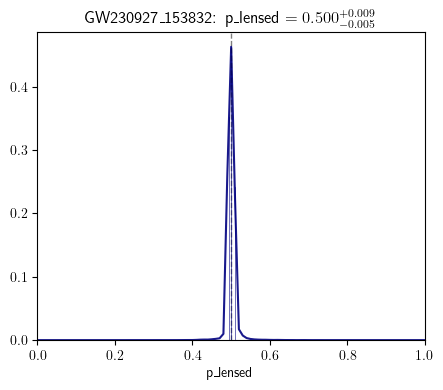

In [11]:
bayes_factors = {}
for (eventname, event_path) in zip(eventname_list, event_dir_list):
    samples, samples_lvk = load_posterior_samples(eventname, event_path)
    if samples is None:
        continue

    # plot the p_lensed distribution
    plot_p_lensed(samples, eventname=eventname)

    # and compute Bayes factor and uncertainty
    bayes_factors_ = bootstrap_bayes_factors(samples, n_resamples)
    bayes_factors[eventname] = (np.median(bayes_factors_), np.std(bayes_factors_))

In [12]:
for eventname, (median, std) in bayes_factors.items():
    print(f"{eventname}:\t{median:.4f} +- {std:.4f}")

GW230518_125908:	1.7278 +- 0.0110
GW230628_231200:	0.8807 +- 0.0022
GW230924_124453:	1.0118 +- 0.0006
GW231108_125142:	1.0182 +- 0.0013
GW231206_233134:	1.0014 +- 0.0003
GW230630_234532:	1.0003 +- 0.0002
GW231206_233901:	0.9881 +- 0.0014
GW231028_153006:	0.9971 +- 0.0008
GW230914_111401:	1.1827 +- 0.0051
GW240104_164932:	1.0113 +- 0.0009
GW231226_101520:	0.9216 +- 0.0024
GW230814_230901:	0.2890 +- 0.0031
GW231102_071736:	1.0491 +- 0.0026
GW230627_015337:	0.9242 +- 0.0020
GW230919_215712:	1.0405 +- 0.0016
GW230927_153832:	1.0026 +- 0.0004


#### what if we multiply the GW230814_230901 waveform by $i$? do we get a symmetric `p_lensed` distribution?

In [31]:
# get event data
eventname = 'GW230814_230901'
catalog = 'GWTC-4.0'
event_table = get_table_data(eventname, catalog)
mchirp_guess = get_chirp_mass(event_table)
t_merger_guess = 0.
approximant = 'IMRPhenomXPHM'
prior_class = 'IntrinsicLVCPrior'
event_data = get_event_data(eventname)

Skipping existing file /home/abbye.williams/cogwheel/cogwheel/data/gwosc_files/GW230814_230901/L_GW230814_230901.hdf5


In [32]:
# fast likelihood marginalization
posterior = cogwheel.posterior.Posterior.from_event(
    event_data,
    mchirp_guess,
    approximant,
    prior_class,
    ref_wf_finder_kwargs={
        'f_ref': 100.0,  # Just so it matches the injection and it makes sense to compare parameters
        'time_range': (t_merger_guess - 0.1, t_merger_guess + 0.1)  # Edit if needed
    }
)

Searching incoherent solution for GW230814_230901
Set intrinsic parameters, lnL = 918.9682938145368
Set time, lnL(L) = 919.2851250237019
Set sky location, lnL = 919.2851250238963
Set phase and distance, lnL = 919.2851250238963
Set mchirp_range = (np.float64(18.759317821078554), np.float64(96.04621355685582))


In [33]:
# now what if we try multiplying the strain by i?
event_data_lensed = get_event_data(eventname)
event_data_lensed.strain *= 1j

posterior_lensed = cogwheel.posterior.Posterior.from_event(
    event_data_lensed,
    mchirp_guess,
    approximant,
    prior_class,
    ref_wf_finder_kwargs={
        'f_ref': 100.0,  # Just so it matches the injection and it makes sense to compare parameters
        'time_range': (t_merger_guess - 0.1, t_merger_guess + 0.1)  # Edit if needed
    }
)

Skipping existing file /home/abbye.williams/cogwheel/cogwheel/data/gwosc_files/GW230814_230901/L_GW230814_230901.hdf5
Searching incoherent solution for GW230814_230901
Set intrinsic parameters, lnL = 918.9682938145368
Set time, lnL(L) = 919.2851250237019
Set sky location, lnL = 919.2851250238963
Set phase and distance, lnL = 919.2851250238963
Set mchirp_range = (np.float64(18.759317821078554), np.float64(96.04621355685582))


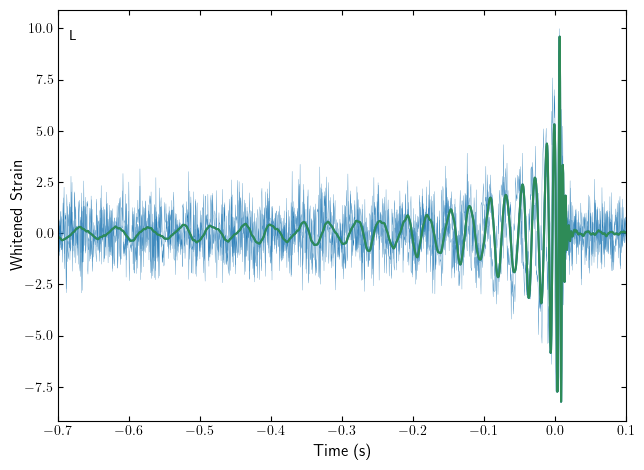

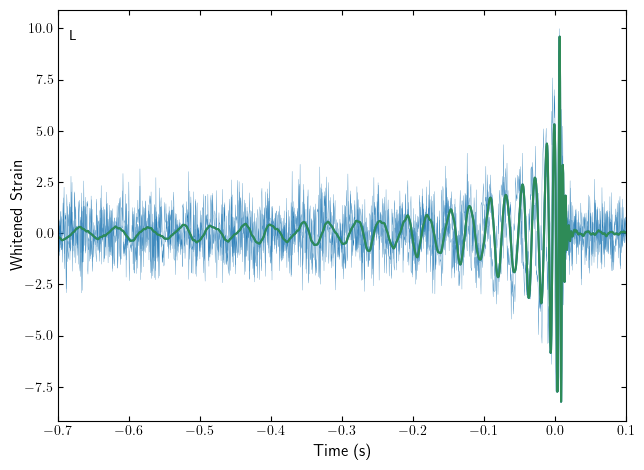

In [34]:
posterior.likelihood.plot_whitened_wf(posterior.likelihood.par_dic_0)
posterior_lensed.likelihood.plot_whitened_wf(posterior_lensed.likelihood.par_dic_0, fig=plt.gcf(), color='seagreen')